In [97]:
import pandas as pd
import numpy as np

In [98]:
df = pd.read_csv("placement_1000.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [99]:
df.shape

(1000, 4)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   cgpa        1000 non-null   float64
 2   iq          1000 non-null   float64
 3   placement   1000 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 31.4 KB


In [101]:
df = df.iloc[:,1:]


In [102]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [103]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model
     

In [104]:
import matplotlib.pyplot as plt

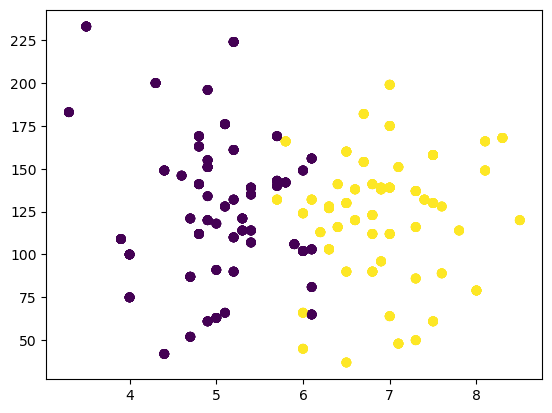

In [105]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [106]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [107]:
x.shape

(1000, 2)

In [108]:
y.shape

(1000,)

In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [110]:
x_train

,cgpa,iq
235,5.7,140.0
744,7.0,175.0
504,5.2,224.0
851,4.7,87.0
475,5.2,110.0
...,...,...
703,6.9,138.0
486,7.0,139.0
249,6.4,116.0
151,7.4,132.0


In [111]:
x_test

,cgpa,iq
956,5.7,169.0
652,6.9,139.0
939,6.5,160.0
165,5.3,114.0
740,4.9,120.0
...,...,...
95,4.3,200.0
201,4.4,149.0
430,6.6,120.0
388,4.8,112.0


In [112]:
y_train

235    0
744    1
504    0
851    0
475    0
      ..
703    1
486    1
249    1
151    1
944    0
Name: placement, Length: 900, dtype: int64

In [113]:
y_test

956    0
652    1
939    1
165    0
740    0
      ..
95     0
201    0
430    1
388    0
288    1
Name: placement, Length: 100, dtype: int64

In [114]:
from sklearn.preprocessing import StandardScaler

In [115]:
scaler = StandardScaler()

In [116]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-0.24277904,  0.35114056],
       [ 0.89206506,  1.23814358],
       [-0.67925754,  2.47994781],
       ...,
       [ 0.36829086, -0.25709008],
       [ 1.24124786,  0.14839701],
       [-0.50466614,  0.22442584]])

In [117]:
x_test = scaler.transform(x_test)
x_test

array([[-0.24277904,  1.08608592],
       [ 0.80476936,  0.32579762],
       [ 0.45558656,  0.85799943],
       [-0.59196184, -0.30777597],
       [-0.94114464, -0.15571831],
       [-1.72680594, -0.66257718],
       [-0.76655324,  1.26348652],
       [-1.02844034, -0.35846186],
       [ 0.45558656,  0.09771113],
       [-1.37762314, -2.13246789],
       [ 0.63017796,  0.70594177],
       [-2.16328444,  2.7080343 ],
       [ 0.71747366, -0.07968948],
       [-0.24277904,  0.42716939],
       [ 1.15395216,  0.27511173],
       [ 2.02690916,  1.06074298],
       [ 2.02690916,  1.06074298],
       [ 0.10640376, -1.1440931 ],
       [-0.50466614, -0.30777597],
       [-0.50466614, -0.48517657],
       [-0.67925754,  0.88334237],
       [ 0.45558656,  0.09771113],
       [ 0.45558656, -0.91600661],
       [ 1.15395216, -1.92972435],
       [-0.24277904,  1.08608592],
       [ 0.28099516, -0.58654835],
       [ 0.36829086,  0.3764835 ],
       [-0.94114464,  0.73128471],
       [-0.76655324,

In [118]:
from sklearn.linear_model import LogisticRegression

In [119]:
clf = LogisticRegression()

In [120]:
clf.fit(x_train,y_train)

LogisticRegression()

In [121]:
y_pred = clf.predict(x_test)

In [122]:
y_pred

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1])

In [123]:
y_test

956    0
652    1
939    1
165    0
740    0
      ..
95     0
201    0
430    1
388    0
288    1
Name: placement, Length: 100, dtype: int64

In [124]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.92

In [125]:
%pip install mlxtend
from mlxtend.plotting import plot_decision_regions

Note: you may need to restart the kernel to use updated packages.


<Axes: >

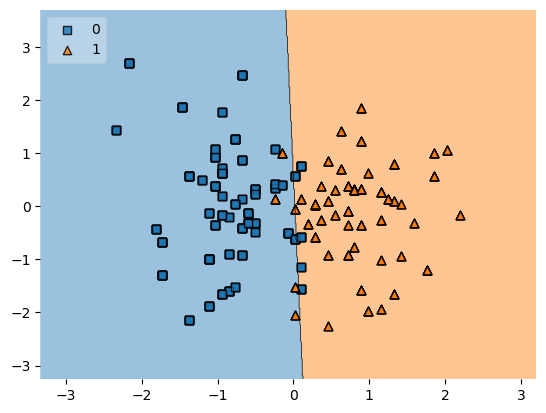

In [126]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [127]:
import pickle

In [128]:
pickle.dump(clf,open('model.pkl','wb'))